📂 Loading Bank Marketing Dataset...

📌 First 5 Rows of Dataset:

   V1            V2       V3         V4  V5    V6   V7   V8       V9  V10  \
0  58    management  married   tertiary  no  2143  yes   no  unknown    5   
1  44    technician   single  secondary  no    29  yes   no  unknown    5   
2  33  entrepreneur  married  secondary  no     2  yes  yes  unknown    5   
3  47   blue-collar  married    unknown  no  1506  yes   no  unknown    5   
4  33       unknown   single    unknown  no     1   no   no  unknown    5   

   V11  V12  V13  V14  V15      V16 Class  
0  may  261    1   -1    0  unknown     1  
1  may  151    1   -1    0  unknown     1  
2  may   76    1   -1    0  unknown     1  
3  may   92    1   -1    0  unknown     1  
4  may  198    1   -1    0  unknown     1  

📊 Dataset Shape: (45211, 17)

🧾 Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype   
---  -

c:\Users\Anuj kumar\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


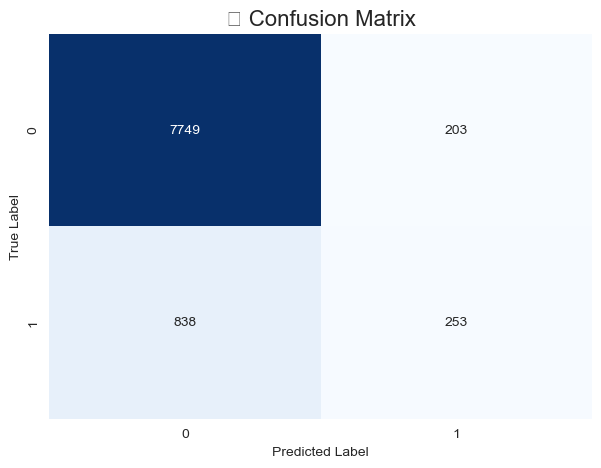

C:\Users\Anuj kumar\AppData\Local\Temp\ipykernel_16920\3786143812.py:168: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(



🔥 Top Important Features:

   Feature  Importance
11     V12    0.620080
8       V9    0.160752
13     V14    0.080569
6       V7    0.065447
10     V11    0.056366
0       V1    0.011288
9      V10    0.002701
12     V13    0.001907
5       V6    0.000890
1       V2    0.000000


c:\Users\Anuj kumar\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


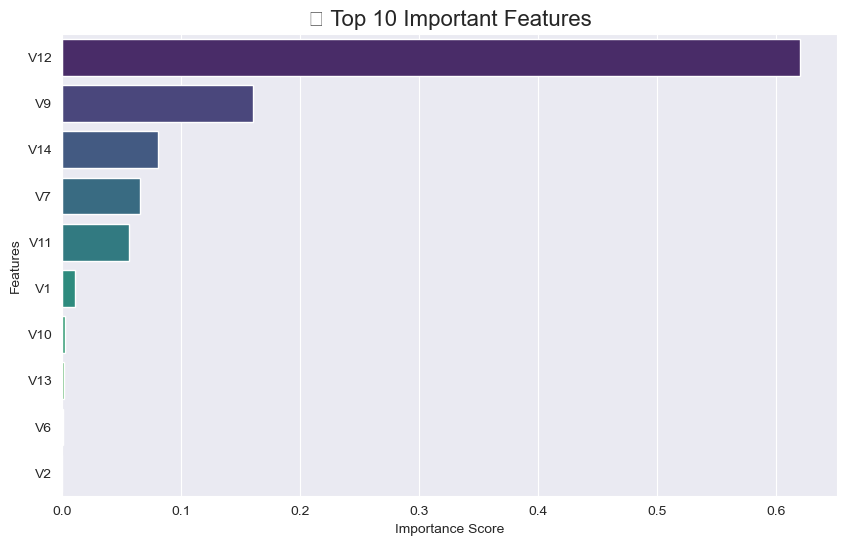

c:\Users\Anuj kumar\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


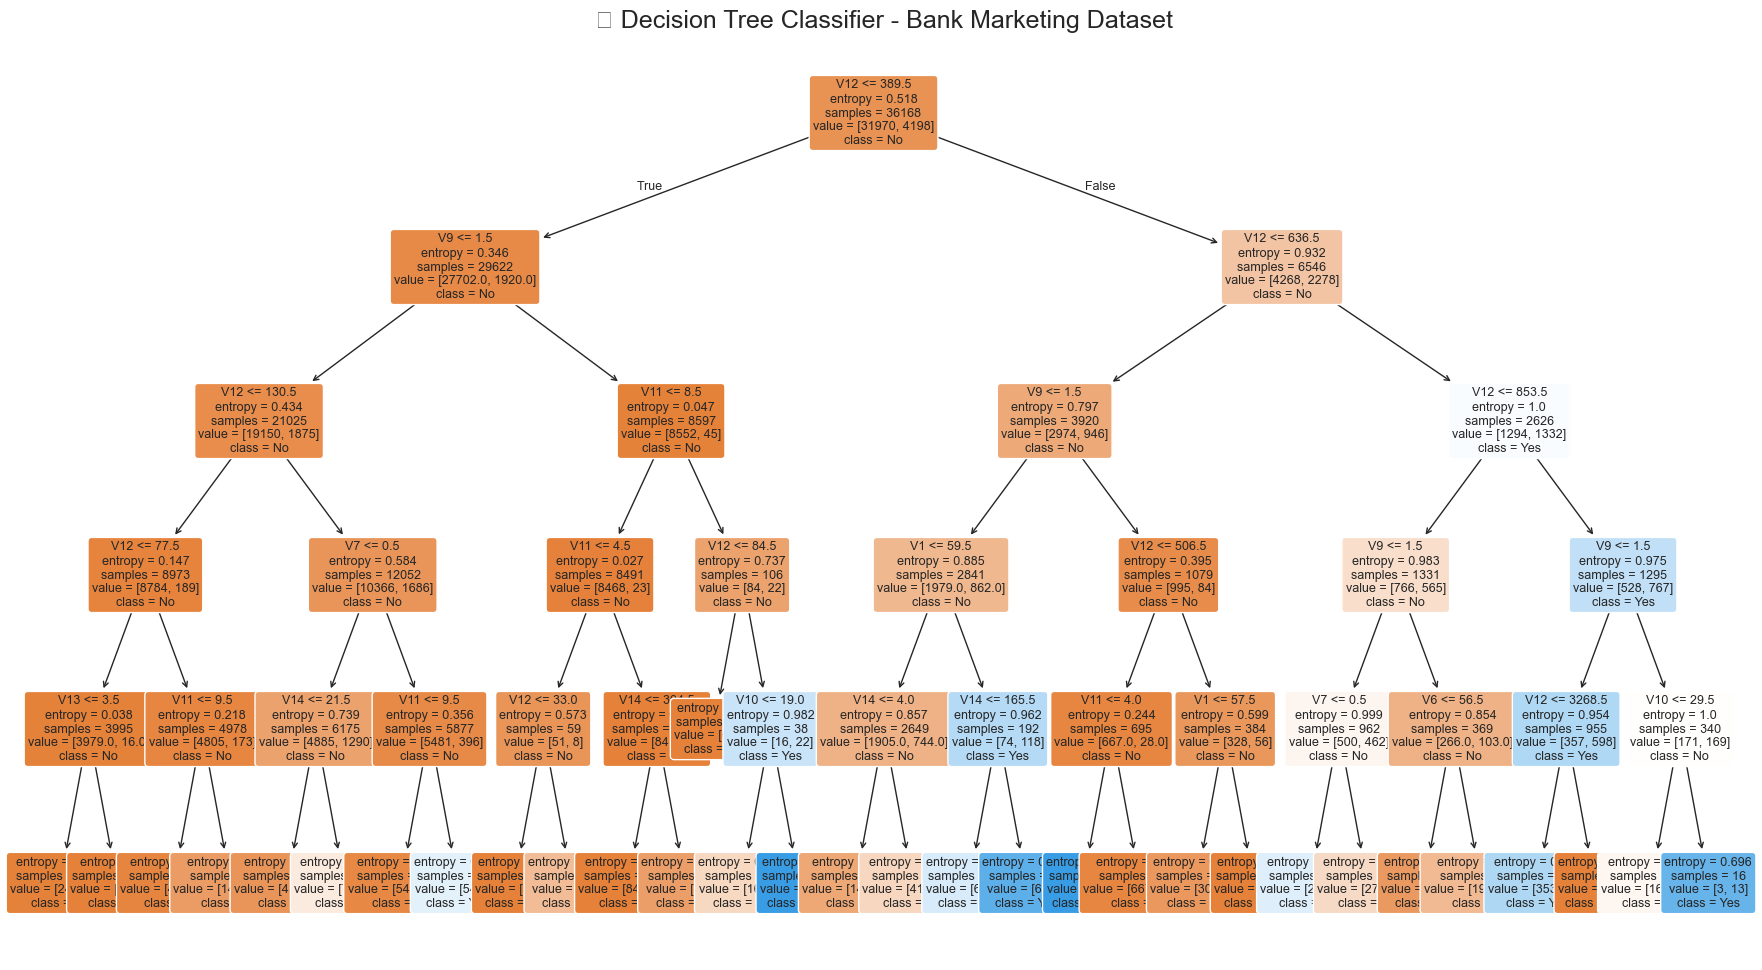


🎉 Project Execution Completed Successfully!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn import tree

# --------------------------------
# Set Plot Style
# --------------------------------
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

# --------------------------------
# Load Dataset
# --------------------------------
print("=" * 60)
print("📂 Loading Bank Marketing Dataset...")
print("=" * 60)

bank = fetch_openml(name='bank-marketing', version=1, as_frame=True)

# Create DataFrame
df = bank.frame.copy()

# --------------------------------
# Display Dataset Information
# --------------------------------
print("\n📌 First 5 Rows of Dataset:\n")
print(df.head())

print("\n📊 Dataset Shape:", df.shape)

print("\n🧾 Dataset Information:\n")
print(df.info())

# --------------------------------
# Handle Categorical Data
# --------------------------------
print("\n🔄 Encoding Categorical Columns...")

label_encoders = {}

for col in df.columns:
    if df[col].dtype == 'object' or str(df[col].dtype) == 'category':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

print("✅ Encoding Completed Successfully!")

# --------------------------------
# Define Features and Target
# --------------------------------
target_column = df.columns[-1]

X = df.drop(columns=[target_column])
y = df[target_column]

print(f"\n🎯 Target Column: {target_column}")

# --------------------------------
# Split Dataset
# --------------------------------
print("\n✂️ Splitting Dataset into Train & Test Sets...")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("✅ Data Split Completed!")
print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")

# --------------------------------
# Create Decision Tree Model
# --------------------------------
print("\n🌳 Training Decision Tree Classifier...")

model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42
)

# Train Model
model.fit(X_train, y_train)

print("✅ Model Training Completed!")

# --------------------------------
# Predictions
# --------------------------------
y_pred = model.predict(X_test)

# --------------------------------
# Model Evaluation
# --------------------------------
accuracy = accuracy_score(y_test, y_pred)

print("\n" + "=" * 60)
print("📈 MODEL PERFORMANCE")
print("=" * 60)

print(f"\n✅ Accuracy Score : {accuracy:.4f}")

print("\n📋 Classification Report:\n")
print(classification_report(y_test, y_pred))

# --------------------------------
# Confusion Matrix Visualization
# --------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False
)

plt.title("📌 Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# --------------------------------
# Feature Importance
# --------------------------------
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\n🔥 Top Important Features:\n")
print(importance.head(10))

# Plot Feature Importance
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10),
    palette='viridis'
)

plt.title("⭐ Top 10 Important Features", fontsize=16)
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

# --------------------------------
# Visualize Decision Tree
# --------------------------------
plt.figure(figsize=(22, 12))

tree.plot_tree(
    model,
    filled=True,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    rounded=True,
    fontsize=9
)

plt.title(
    "🌳 Decision Tree Classifier - Bank Marketing Dataset",
    fontsize=18
)

plt.show()

# --------------------------------
# Final Message
# --------------------------------
print("\n" + "=" * 60)
print("🎉 Project Execution Completed Successfully!")
print("=" * 60)